In [1]:
pip install tensorflow scikit-learn matplotlib

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load LFW dataset (people with at least 50 images to simplify)
lfw = fetch_lfw_people(min_faces_per_person=100, resize=0.5, color=True)

X = lfw.images / 255.0  # normalize
y = lfw.target
class_names = lfw.target_names

print("Dataset shape:", X.shape)
print("Number of classes:", len(class_names))


Dataset shape: (1140, 62, 47, 3)
Number of classes: 5


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [17]:
input_shape = X_train.shape[1:]  # (h, w, 3)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 60, 45, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,147,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,167,045 (4.45 MB)

 Trainable params: 1,167,045 (4.45 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train_cat,
    epochs=100, batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.4117 - loss: 1.5257 - val_accuracy: 0.4386 - val_loss: 1.4347
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.4639 - loss: 1.4495 - val_accuracy: 0.4386 - val_loss: 1.4183
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.4810 - loss: 1.4029 - val_accuracy: 0.4386 - val_loss: 1.4242
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.4540 - loss: 1.4452 - val_accuracy: 0.4386 - val_loss: 1.4190
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.5019 - loss: 1.4301 - val_accuracy: 0.4386 - val_loss: 1.4234
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.4847 - loss: 1.4025 - val_accuracy: 0.4386 - val_loss: 1.4252
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.4742 - loss: 1.4224 - val_accuracy: 0.4386 - val_loss: 1.4221
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.4774 - loss: 1.4219 - val_accu

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")


Test accuracy: 0.814


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


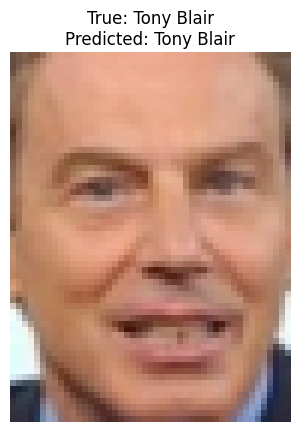

In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Pick a random test image
i = random.randint(0, len(X_test) - 1)
img = X_test[i]

# Predict the label
pred = np.argmax(model.predict(img[np.newaxis, ...]))
pred_name = class_names[pred]
true_name = class_names[y_test[i]]

# Display correctly in RGB
plt.imshow(img.astype("float32") / np.max(img))
plt.axis("off")
plt.title(f"True: {true_name}\nPredicted: {pred_name}")
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


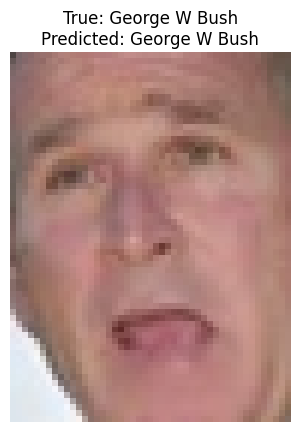

In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Pick a random test image
i = random.randint(0, len(X_test) - 1)
img = X_test[i]

# Predict the label
pred = np.argmax(model.predict(img[np.newaxis, ...]))
pred_name = class_names[pred]
true_name = class_names[y_test[i]]

# Display correctly in RGB
plt.imshow(img.astype("float32") / np.max(img))
plt.axis("off")
plt.title(f"True: {true_name}\nPredicted: {pred_name}")
plt.show()

